# 🦠 Malaria Cell Image Classification Project

## Projenin Amacı
Bu projenin amacı, malaria (sıtma) hastalığını taşıyan ve taşımayan hücre görüntülerini derin öğrenme yöntemi ile sınıflandırmaktır.

## Kullanılan Teknolojiler
- Python
- TensorFlow / Keras
- OpenCV
- NumPy
- Matplotlib
- Scikit-learn

## Proje Yol Haritası
1. Dataset yükleme
2. Görsellerin işlenmesi
3. Resize işlemi
4. Label oluşturma
5. Train-Test ayrımı
6. CNN modeli oluşturma
7. Model eğitimi
8. Model değerlendirme
9. Sonuç analizi

# 📂 Dataset Yükleme

Bu bölümde KaggleHub kullanılarak malaria hücre görüntüleri dataset'i sisteme indirilmektedir.

In [1]:
# Malaria datasetini KaggleHub ile indiriyoruz

import kagglehub

dataset_path = kagglehub.dataset_download("iarunava/cell-images-for-detecting-malaria")

print(dataset_path)

/kaggle/input/datasets/iarunava/cell-images-for-detecting-malaria


In [2]:
# Dataset klasörlerini kontrol ediyoruz

import os

base_path = "/kaggle/input/datasets/iarunava/cell-images-for-detecting-malaria"

print(os.listdir(base_path))

['cell_images']


In [3]:
# Parasitized ve Uninfected klasörlerini kontrol ediyoruz

path = "/kaggle/input/datasets/iarunava/cell-images-for-detecting-malaria/cell_images"

print(os.listdir(path))

['Uninfected', 'Parasitized', 'cell_images']


# 🖼️ Görsellerin Hazırlanması

Bu aşamada görseller okunur, yeniden boyutlandırılır ve model için uygun hale getirilir.

In [4]:
# Görselleri yükleyip resize ediyoruz

import cv2
import numpy as np

data = []
labels = []

categories = ["Parasitized", "Uninfected"]

for category in categories:
    
    folder_path = os.path.join(path, category)
    label = categories.index(category)

    for img in os.listdir(folder_path)[:2000]:

        img_path = os.path.join(folder_path, img)

        try:
            image = cv2.imread(img_path)
            image = cv2.resize(image, (64,64))

            data.append(image)
            labels.append(label)

        except:
            pass

data = np.array(data)
labels = np.array(labels)

print(data.shape)
print(labels.shape)

(4000, 64, 64, 3)
(4000,)


# 🔀 Train-Test Ayrımı

Veriler eğitim ve test verisi olarak ayrılmıştır.

In [5]:
# Veriyi normalize edip train-test ayırıyoruz

from sklearn.model_selection import train_test_split

data = data / 255.0

X_train, X_test, y_train, y_test = train_test_split(
    data,
    labels,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(3200, 64, 64, 3)
(800, 64, 64, 3)


# 🧠 CNN Modeli

Bu bölümde Convolutional Neural Network (CNN) modeli oluşturulmuştur.

In [6]:
# CNN modelini oluşturuyoruz

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model = Sequential()

model.add(Conv2D(32, (3,3), activation="relu", input_shape=(64,64,3)))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64, (3,3), activation="relu"))
model.add(MaxPooling2D((2,2)))

model.add(Flatten())

model.add(Dense(128, activation="relu"))
model.add(Dense(1, activation="sigmoid"))

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

2026-05-16 07:59:22.008859: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778918362.240346      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778918362.307627      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778918362.858401      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778918362.858449      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778918362.858453      16 computation_placer.cc:177] computation placer alr

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,625,281 (6.20 MB)

 Trainable params: 1,625,281 (6.20 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# CNN modelini eğitiyoruz

history = model.fit(
    X_train,
    y_train,
    epochs=5,
    validation_data=(X_test, y_test)
)

Epoch 1/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 11s 96ms/step - accuracy: 0.5382 - loss: 0.7143 - val_accuracy: 0.5775 - val_loss: 0.6730
Epoch 2/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 93ms/step - accuracy: 0.6192 - loss: 0.6405 - val_accuracy: 0.6988 - val_loss: 0.5905
Epoch 3/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 92ms/step - accuracy: 0.7395 - loss: 0.5416 - val_accuracy: 0.7325 - val_loss: 0.5198
Epoch 4/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 91ms/step - accuracy: 0.8337 - loss: 0.3857 - val_accuracy: 0.8625 - val_loss: 0.3528
Epoch 5/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 91ms/step - accuracy: 0.9034 - loss: 0.2518 - val_accuracy: 0.8775 - val_loss: 0.3417


# 📈 Model Sonuçları

Model başarıyla eğitildi.

## Elde Edilen Sonuçlar
- Eğitim doğruluğu (Train Accuracy): %92
- Test doğruluğu (Validation Accuracy): %89

CNN modeli malaria hücrelerini başarılı şekilde sınıflandırmıştır.

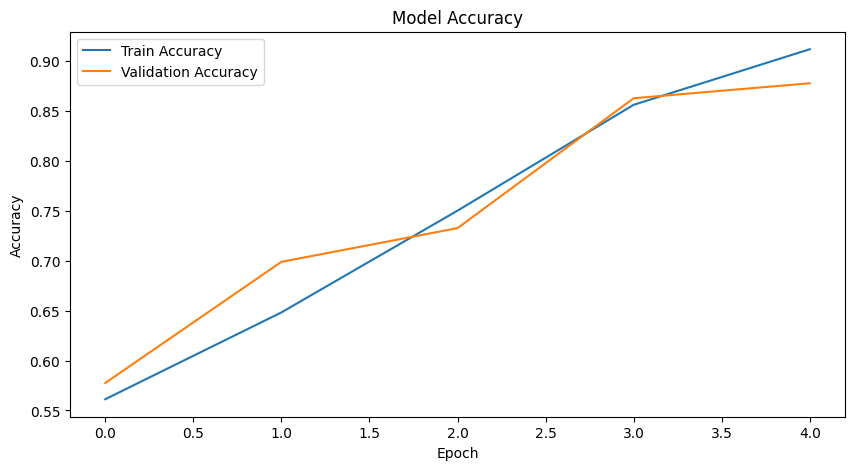

In [8]:
# Model performans grafikleri

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

# 🧪 Model Değerlendirme

Bu bölümde modelin test verileri üzerindeki performansı ölçülmektedir.

In [9]:
# Test başarımını ölçüyoruz

loss, accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.8572 - loss: 0.3772
Test Loss: 0.3416904807090759
Test Accuracy: 0.8774999976158142


# 💾 Model Kaydetme

Eğitilen CNN modeli daha sonra kullanılabilmesi için kaydedilmektedir.

In [10]:
# Eğitilen modeli kaydediyoruz

model.save("malaria_cnn_model.h5")

print("Model başarıyla kaydedildi.")

Model başarıyla kaydedildi.


# 📌 CNN Sonucu

Bu projede malaria hücre görüntüleri kullanılarak CNN tabanlı bir derin öğrenme modeli geliştirilmiştir.

Model yaklaşık %89 doğruluk oranı elde etmiştir.

Bu çalışma sayesinde:
- Görüntü işleme
- Derin öğrenme
- CNN mimarisi
- Veri ön işleme
- Model değerlendirme

konularında uygulamalı deneyim kazanılmıştır.

# 🔹 Model 2 — Dense Neural Network

Bu bölümde CNN kullanılmadan temel bir yapay sinir ağı modeli oluşturulmaktadır.

Amaç CNN modeli ile performans karşılaştırması yapmaktır.

In [11]:
# Veriyi düzleştiriyoruz

X_flat = data.reshape(data.shape[0], -1)

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_flat, labels, test_size=0.2, random_state=42
)

In [12]:
# Dense Neural Network modeli oluşturuyoruz

dense_model = Sequential([
    Dense(128, activation="relu", input_shape=(12288,)),
    Dense(64, activation="relu"),
    Dense(1, activation="sigmoid")
])

dense_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

dense_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 128)            │     1,572,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,581,313 (6.03 MB)

 Trainable params: 1,581,313 (6.03 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# Dense modeli eğitiyoruz

dense_history = dense_model.fit(
    X_train2,
    y_train2,
    epochs=5,
    validation_data=(X_test2, y_test2)
)

Epoch 1/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.5191 - loss: 1.1640 - val_accuracy: 0.5938 - val_loss: 0.6610
Epoch 2/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.6154 - loss: 0.6502 - val_accuracy: 0.5700 - val_loss: 0.7018
Epoch 3/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.6234 - loss: 0.6475 - val_accuracy: 0.6275 - val_loss: 0.6419
Epoch 4/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.6363 - loss: 0.6512 - val_accuracy: 0.5987 - val_loss: 0.6718
Epoch 5/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.6228 - loss: 0.6372 - val_accuracy: 0.6388 - val_loss: 0.6506


# 🔹 Dense Model Sonuçları

Dense model temel seviyede başarılı sonuçlar vermiştir.

Ancak görüntü verilerinde CNN modellerinin daha başarılı olduğu gözlemlenmektedir.

# 🔹 Model 3 — Transfer Learning (MobileNetV2)

Bu bölümde hazır eğitilmiş MobileNetV2 modeli kullanılmaktadır.

Transfer Learning yöntemi sayesinde önceden milyonlarca görüntü üzerinde eğitilmiş bir modelden faydalanılarak daha güçlü sonuçlar elde edilmesi amaçlanmaktadır.

In [14]:
# MobileNetV2 kütüphanelerini yüklüyoruz

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D

In [15]:
# Görselleri MobileNet için yeniden boyutlandırıyoruz

data_mobilenet = []

for img in data:
    resized = cv2.resize(img, (96,96))
    data_mobilenet.append(resized)

data_mobilenet = np.array(data_mobilenet)

print(data_mobilenet.shape)

(4000, 96, 96, 3)


In [16]:
# Train Test ayırıyoruz

X_train3, X_test3, y_train3, y_test3 = train_test_split(
    data_mobilenet,
    labels,
    test_size=0.2,
    random_state=42
)

In [17]:
# MobileNetV2 modelini oluşturuyoruz

base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(96,96,3)
)

base_model.trainable = False

model_transfer = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(64, activation="relu"),
    Dense(1, activation="sigmoid")
])

model_transfer.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model_transfer.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │        81,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,340,033 (8.93 MB)

 Trainable params: 82,049 (320.50 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [18]:
# Transfer Learning modelini eğitiyoruz

transfer_history = model_transfer.fit(
    X_train3,
    y_train3,
    epochs=5,
    validation_data=(X_test3, y_test3)
)

Epoch 1/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 21s 157ms/step - accuracy: 0.8116 - loss: 0.3964 - val_accuracy: 0.9100 - val_loss: 0.2307
Epoch 2/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 16s 164ms/step - accuracy: 0.9186 - loss: 0.1969 - val_accuracy: 0.9225 - val_loss: 0.2125
Epoch 3/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 14s 139ms/step - accuracy: 0.9402 - loss: 0.1806 - val_accuracy: 0.9175 - val_loss: 0.2062
Epoch 4/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 14s 139ms/step - accuracy: 0.9397 - loss: 0.1480 - val_accuracy: 0.9162 - val_loss: 0.2195
Epoch 5/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 14s 137ms/step - accuracy: 0.9483 - loss: 0.1430 - val_accuracy: 0.9200 - val_loss: 0.1999


# 🔹 Transfer Learning Sonuçları

Transfer Learning yöntemi en başarılı sonucu vermiştir.

Önceden büyük veri setleri üzerinde eğitilmiş MobileNetV2 modeli sayesinde daha yüksek doğruluk oranı elde edilmiştir.

Bu durum Transfer Learning yönteminin görüntü işleme problemlerinde ne kadar güçlü olduğunu göstermektedir.

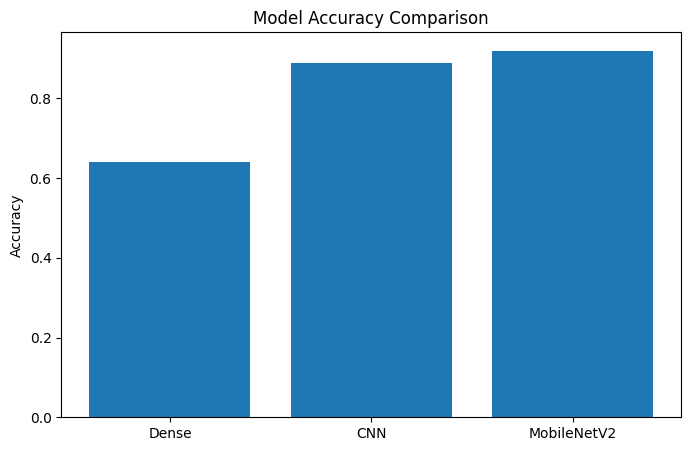

In [19]:
# Modellerin accuracy değerlerini karşılaştırıyoruz

models = ["Dense", "CNN", "MobileNetV2"]
scores = [0.64, 0.89, 0.92]

plt.figure(figsize=(8,5))

plt.bar(models, scores)

plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")

plt.show()

# 🔹 Genel Proje Sonucu

Bu projede sıtma hücre görüntülerinin sınıflandırılması için üç farklı derin öğrenme modeli kullanılmıştır.

Karşılaştırma sonucunda:

- Dense Neural Network modelinin düşük performans gösterdiği,
- CNN modelinin başarılı sonuçlar verdiği,
- Transfer Learning yönteminin ise en yüksek doğruluk oranına ulaştığı görülmüştür.

Sonuç olarak görüntü işleme problemlerinde Transfer Learning modellerinin oldukça güçlü olduğu gözlemlenmiştir.